In [1]:
%pylab inline

# import warnings;
# warnings.filterwarnings('ignore');

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
# from mpl_toolkits.mplot3d import Axes3D

from matplotlib import rc
rc('text', usetex=True)
# rc('font', family='Times New Roman', size='20')
fontsize = 22
params = {
    'font.family': 'Times New Roman',
#     'font.weight': 150,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize ,
    'xtick.labelsize': fontsize-2,
    'ytick.labelsize': fontsize-2,
    'legend.fontsize': fontsize-5,
}
rcParams.update(params)

Duplicate key in file '/Users/chigamma/.matplotlib/matplotlibrc' line #2.

Bad key "“backend" on line 2 in
/Users/chigamma/.matplotlib/matplotlibrc.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
import argparse
import re

In [6]:
def geteacc(acc_lst, acc=80):
    for i, v in enumerate(acc_lst):
        if v >= acc:
            break
    return i

def comm(siz_lst, i, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:i+1])
    return res

def commE(siz_lst, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:100])
        if len(siz_lst[client]) > 100:
            print("Warning")
    return res

def get_onef(d, f, epc=100):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
        print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        it = re.finditer(
            r'\[Client  {}\]  Param Before: \d+\.\d+e\+\d+,  After: (\d+\.\d+e\+\d+)'.format(client), s)
        siz_lst[client] = []
        for i in it:
            siz_lst[client].append(float(i.group(1)))
            
    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)
    
    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

def get_oneb(d, f, siz, epc=100):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
#     print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != epc:
#         print("Warning", d, f, len(acc_lst))
        acc_lst = acc_lst[:epc]

    siz_lst = {}
    for client in range(10):
        siz_lst[client] = [siz] * epc

    comm_lst = [0]
    for i in range(epc):
        comm = comm_lst[i]
        for c in range(10):
            comm += siz_lst[c][i]
        comm_lst.append(comm)

    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
           'siz': siz_lst,
           'comm': comm_lst}
    return dic

In [7]:
issave = False

In [25]:
d = {}
nlst = []
flst = []
dr = 'PowerGDP'

# flst += ['0521-258fe4', '0527-e79885', '0521-c4d818', '0528-753352', '0528-1f53d6']
# epslst = ['5', '6', '7', '9', '10']
# for eps in epslst:
#     nlst.append('16' + '-' + eps)
    
# flst += ['0515-3f85d2', '0515-dc9ba1', '0515-ce1514', '0515-be74ba', '0520-140bfb', ]
# epslst = ['5', '6', '7', '9', '10']
# for eps in epslst:
#     nlst.append('8' + '-' + eps)
    
flst += ['0730-04cf12', '0730-9a5b7f', '0730-63d390', '0730-01f0c6', '0730-28e251', '0730-2ba98d', ]
epslst = ['2', '5', '6', '7', '9', '10']
for eps in epslst:
    nlst.append('4' + '-' + eps)

flst += ['0730-97b6d4', '0730-97b6d4', '0730-c00321', '0730-a1905a', '0730-ea4c16', '0730-9cadea', ]
epslst = ['2', '5', '6', '7', '9', '10']
for eps in epslst:
    nlst.append('2' + '-' + eps)

for f, n in zip(flst, nlst):
    d[n] = get_onef(dr, f)
    
dr = 'PowerAvg'
flst = ['0630-8e075d', '0630-01010d', '0630-0f956b', '0630-c69bd2', '0630-861948', ]
nlst = ['32-0', '16-0', '8-0', '4-0', '2-0']

for f, n in zip(flst, nlst):
    d[n] = get_onef(dr, f)

d['b'] = get_oneb('FedAvg', '0622-e67d6c', siz=6.4972e6, epc=100)

In [23]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-', 'lw': 4, 'marker': 'o', 'ms': 12, 'alpha': 0.85}
sp = {'ls': '-', 'lw': 4, 'marker': 'D', 'ms': 12, 'alpha': 0.8}

lb = ['FedAvg', 'FedASI-DP $k=8$', 'FedASI-DP $k=4$', 'FedASI-DP $k=2$', 'FedASI-DP $k=16$']

In [26]:
acb = max(d['b']['acc'])
c8b = d['b']['comm'][10]
ceb = d['b']['comm'][100]
szb = d['b']['siz'][0][0]

rt_l, ac_l, c8_l, ce_l = {}, {}, {}, {}
epslst = {'16':['0', '5', '6', '7', '9', '10'],
          '8': ['0', '5', '6', '7', '9', '10'],
          '4': ['0', '2', '5', '6', '7', '9', '10'],
          '2': ['0', '2', '5', '6', '7', '9', '10']}
# rnklst = ['16', '8', '4', '2']
rnklst = ['4', '2']

for rnk in rnklst:
    rt_l[rnk] = [d[rnk+'-'+eps]['siz'][0][0] / szb * 100 for eps in epslst[rnk]]
    ac_l[rnk] = [max(d[rnk+'-'+eps]['acc']) for eps in epslst[rnk]]
    c8_l[rnk] = [d[rnk+'-'+eps]['comm'][geteacc(d[rnk+'-'+eps]['acc'], acc=80)] for eps in epslst[rnk]]
    ce_l[rnk] = [d[rnk+'-'+eps]['comm'][100] for eps in epslst[rnk]]

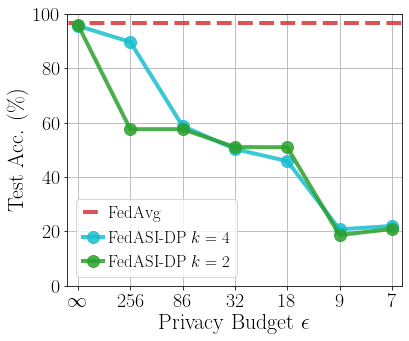

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot([0, 10], [acb, acb], c=cm[6], label=lb[0], 
        ls='--', lw=4, alpha=0.8)

rt_l = [1, 2, 3, 4, 5, 6, 7]
# ax.plot(rt_l[:6], ac_l['16'], c=cm[8], label=lb[4], **st)
# ax.plot(rt_l[:6], ac_l['8'], c=cm[0] , label=lb[1], **st)
ax.plot(rt_l    , ac_l['4'], c=cm[18], label=lb[2], **st)
ax.plot(rt_l    , ac_l['2'], c=cm[4] , label=lb[3], **st)

ax.set(xlim=[0.8, 7.2], ylim=[0, 100], 
       xticks=[1, 2, 3, 4, 5, 6, 7],
       xticklabels=['$\\infty$', '256', '86', '32', '18', '9', '7',],
       xlabel='Privacy Budget $\\epsilon$', ylabel='Test Acc. (\%)')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=1, loc=3, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_6asiper_accVeps_cnn.pdf', bbox_inches='tight')

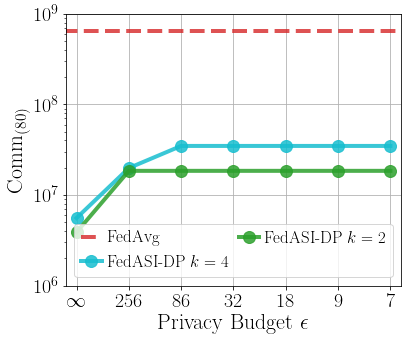

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.semilogy([-10, 25], [c8b, c8b], c=cm[6], label=lb[0], 
            ls='--', lw=4, alpha=0.8)

# ax.semilogy([1, 2, 3, 4, 5, 6]   , c8_l['8'], c=cm[0] , label=lb[1], **st)
ax.semilogy([1, 2, 3, 4, 5, 6, 7], c8_l['4'], c=cm[18], label=lb[2], **st)
ax.semilogy([1, 2, 3, 4, 5, 6, 7], c8_l['2'], c=cm[4] , label=lb[3], **st)

ax.set(xlim=[0.8, 7.2], ylim=[1e6, 1e9], 
       xticks=[1, 2, 3, 4, 5, 6, 7],
       xticklabels=['$\\infty$', '256', '86', '32', '18', '9', '7',],
       xlabel='Privacy Budget $\\epsilon$', ylabel='$\\mathrm{Comm_{(80)}}$')
ax.grid(True, axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=2, loc=8, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
# fig.savefig('./figs/fig_6asiper_cm8Veps_rsn.pdf', bbox_inches='tight')